# Visualizing DINOv3 features on RELLIS-3D images

DINOv3 never tells us "this is grass" or "this is a tree". It turns an image into a grid of
**feature vectors**: the 704×704 input is split into 16×16 patches, giving a **44×44 grid**,
and each grid cell gets a vector of **384 numbers** describing what that patch looks like.

Those numbers are meaningless one by one — but patches that *look similar* (two patches of
grass) get *similar vectors*, and patches that look different (grass vs. tree) get different
ones. That property is exactly what the STEPP autoencoder relies on.

This notebook makes the features visible in four ways:
1. **Single channels** — a few of the 384 numbers shown as heatmaps.
2. **PCA color image** — compress all 384 numbers per patch into 3 numbers and show them as
   red/green/blue. Similar terrain gets similar colors (the classic DINO visualization).
3. **Similarity maps** — pick a point on the image (e.g. on the trail) and color every patch
   by how similar its feature is to that point's feature.
4. **PCA across several images** — the same PCA applied to different images, to see that the
   same terrain type gets the same color in every image.

## 0. Settings

In [1]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')
OUT_DIR   = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/outputs/viz_dinov3')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# DINOv3 code folder and the downloaded weights
DINOV3_REPO    = Path('C:/Users/jthre/.cache/torch/hub/facebookresearch_dinov3_main')
DINOV3_WEIGHTS = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/DinoV3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth')

# the main image to visualize: frame number IMAGE_INDEX of this sequence
# (you can also just set IMAGE_PATH to any image file directly)
MAIN_SEQ    = '00000'
IMAGE_INDEX = 104
IMAGE_PATH  = sorted((DATA_ROOT / MAIN_SEQ / 'pylon_camera_node').glob('*.jpg'))[IMAGE_INDEX]

# a few more images for the multi-image PCA at the end
EXTRA_IMAGES = [
    DATA_ROOT / '00001' / 'pylon_camera_node',
    DATA_ROOT / '00002' / 'pylon_camera_node',
]

INPUT_SIZE = 704      # DINOv3 ViT-S/16: 704 / 16 = 44x44 grid
PATCH      = 16
GRID       = INPUT_SIZE // PATCH

print('image:', IMAGE_PATH.name)
print(f'grid: {GRID}x{GRID} patches, 384 numbers per patch')
assert IMAGE_PATH.is_file(), f'image not found: {IMAGE_PATH}'

image: frame000104-1581624663_149.jpg
grid: 44x44 patches, 384 numbers per patch


## 1. Load DINOv3 and define the feature extractor

In [2]:
import sys
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import cv2
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# import DINOv3 directly from its code folder (avoids extra dependencies)
sys.path.insert(0, str(DINOV3_REPO))
from dinov3.hub.backbones import dinov3_vits16
model = dinov3_vits16(weights=str(DINOV3_WEIGHTS)).to(device).eval()
for p in model.parameters():
    p.requires_grad = False

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def load_square_image(path):
    """Read an image file and return it as a 704x704 RGB picture."""
    bgr = cv2.imread(str(path))
    assert bgr is not None, f'could not read {path}'
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return cv2.resize(rgb, (INPUT_SIZE, INPUT_SIZE))

def get_feature_map(square_rgb):
    """704x704 RGB picture -> numpy array of shape (44, 44, 384)."""
    image = torch.from_numpy(square_rgb).permute(2, 0, 1).float() / 255.0
    image = normalize(image).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = model.get_intermediate_layers(image, n=1)[0][0]   # (44*44, 384)
    return tokens.reshape(GRID, GRID, 384).cpu().numpy()

square = load_square_image(IMAGE_PATH)
features = get_feature_map(square)
print('feature map shape:', features.shape)

device: cuda
feature map shape: (44, 44, 384)


## 2. Single feature channels

Each of the 384 numbers is one "channel". A single channel is like one question the network
asks about every patch (we don't know which question — the network invented them during its
own training). Some channels light up on vegetation, some on the ground, some on the sky.
Bright = high value, dark = low value.

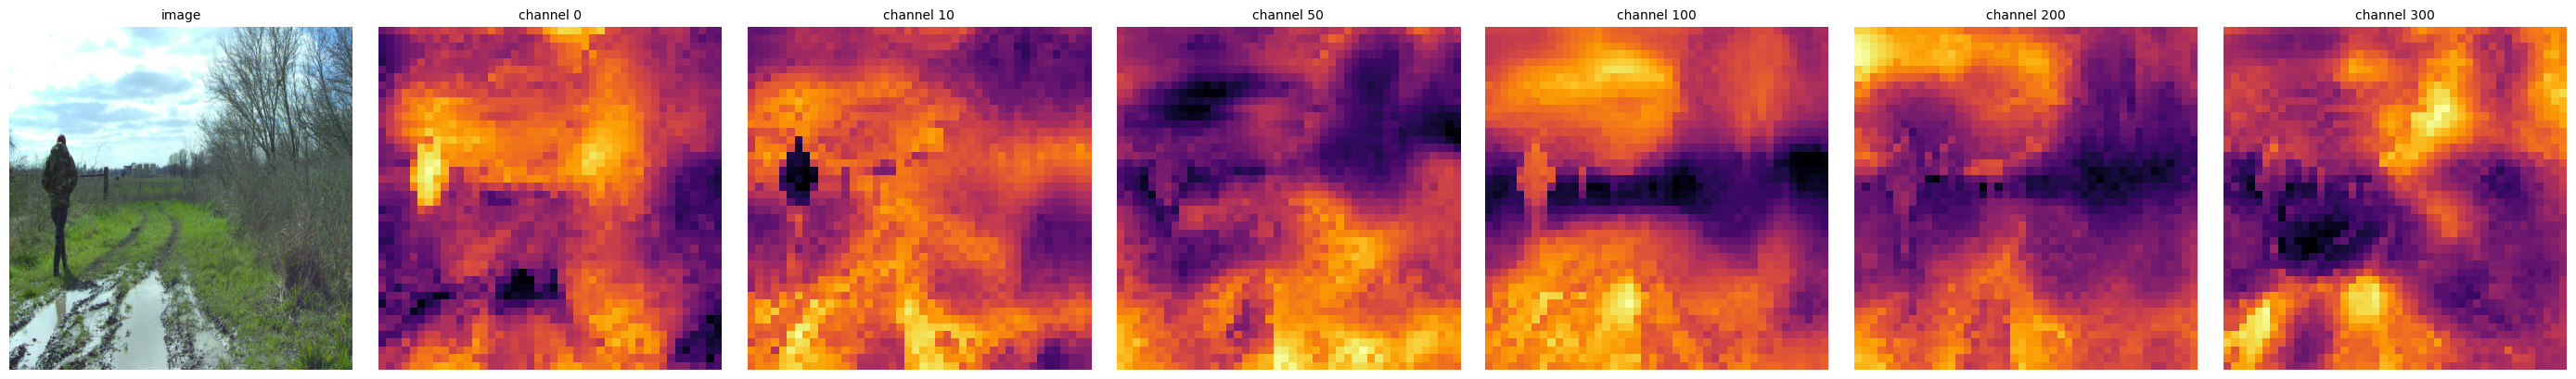

In [3]:
CHANNELS_TO_SHOW = [0, 10, 50, 100, 200, 300]   # between 0 and 383

fig, axes = plt.subplots(1, len(CHANNELS_TO_SHOW) + 1, figsize=(4 * (len(CHANNELS_TO_SHOW) + 1), 4))
axes[0].imshow(square)
axes[0].set_title('image', fontsize=10)
for ax, channel in zip(axes[1:], CHANNELS_TO_SHOW):
    one_channel = features[:, :, channel]              # (44, 44)
    ax.imshow(one_channel, cmap='inferno')
    ax.set_title(f'channel {channel}', fontsize=10)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'channels.png', dpi=120)
plt.show()

## 3. PCA color image - all 384 channels at once

We cannot look at 384 heatmaps, so we compress: **PCA** finds the 3 directions along which
the 1936 patch vectors differ the most, and we paint those 3 values as **red, green, blue**.

The colors themselves mean nothing — what matters is that **patches with the same color have
similar features**. Terrain types separate into distinct colors even though DINOv3 was never
told what grass or trees are.

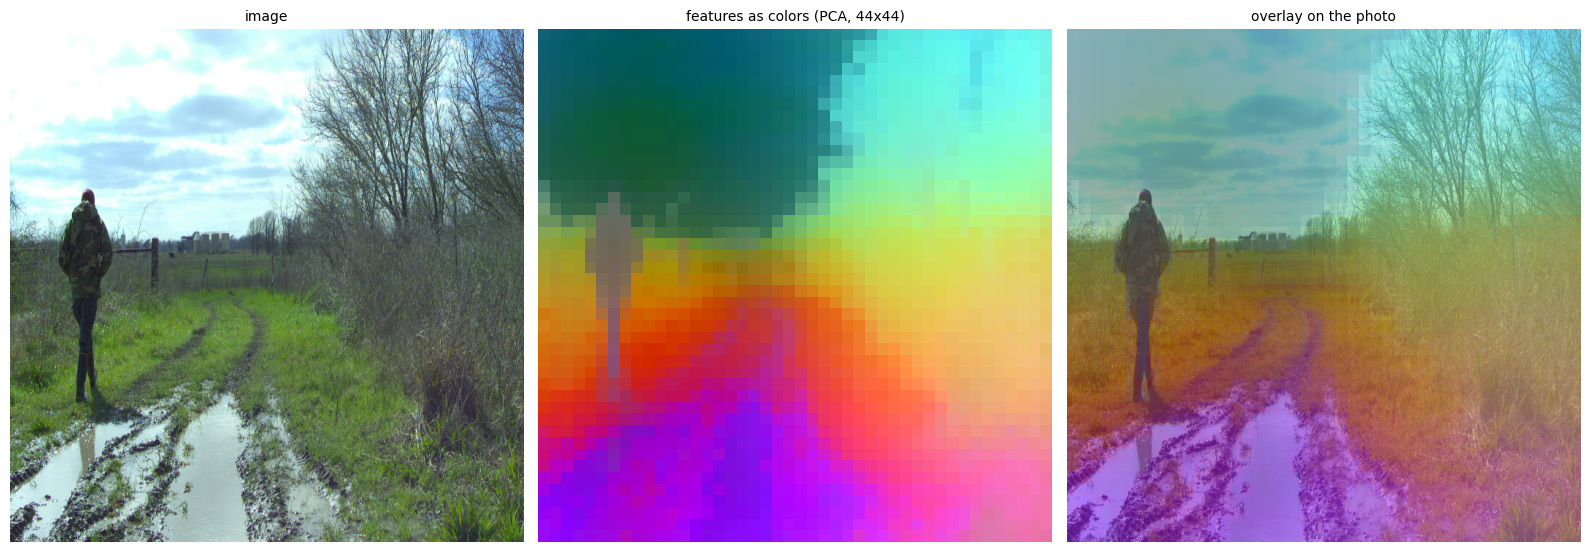

In [4]:
def pca_color_image(feature_map, pca=None):
    """Compress (44,44,384) features to a (44,44,3) color image using PCA."""
    flat = feature_map.reshape(-1, feature_map.shape[2])     # (1936, 384)
    if pca is None:
        pca = PCA(n_components=3)
        pca.fit(flat)
    compressed = pca.transform(flat)                          # (1936, 3)
    # stretch each of the 3 columns to the range 0..1 so it can be a color
    low  = np.percentile(compressed, 2, axis=0)
    high = np.percentile(compressed, 98, axis=0)
    colors = (compressed - low) / (high - low)
    colors = np.clip(colors, 0, 1)
    return colors.reshape(feature_map.shape[0], feature_map.shape[1], 3), pca

pca_image, pca = pca_color_image(features)

# also blow the small 44x44 color image up to 704x704 to overlay it on the photo
pca_big = cv2.resize(pca_image, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_NEAREST)
blend = (0.5 * square / 255.0 + 0.5 * pca_big)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(square);    axes[0].set_title('image', fontsize=10)
axes[1].imshow(pca_image); axes[1].set_title('features as colors (PCA, 44x44)', fontsize=10)
axes[2].imshow(blend);     axes[2].set_title('overlay on the photo', fontsize=10)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca.png', dpi=120)
plt.show()

## 4. Similarity maps - "what else looks like this point?"

Pick a point on the image. We take the feature vector of the patch under that point and
compute the **cosine similarity** (how aligned two vectors are, 1 = identical direction) to
every other patch. Bright = similar.

Pick a point on the **trail** and the whole drivable ground lights up; pick a **tree** and
the vegetation lights up. This is the property that makes traversability learning work:
\"terrain the robot drove on\" has features similar to *all* the other drivable terrain.

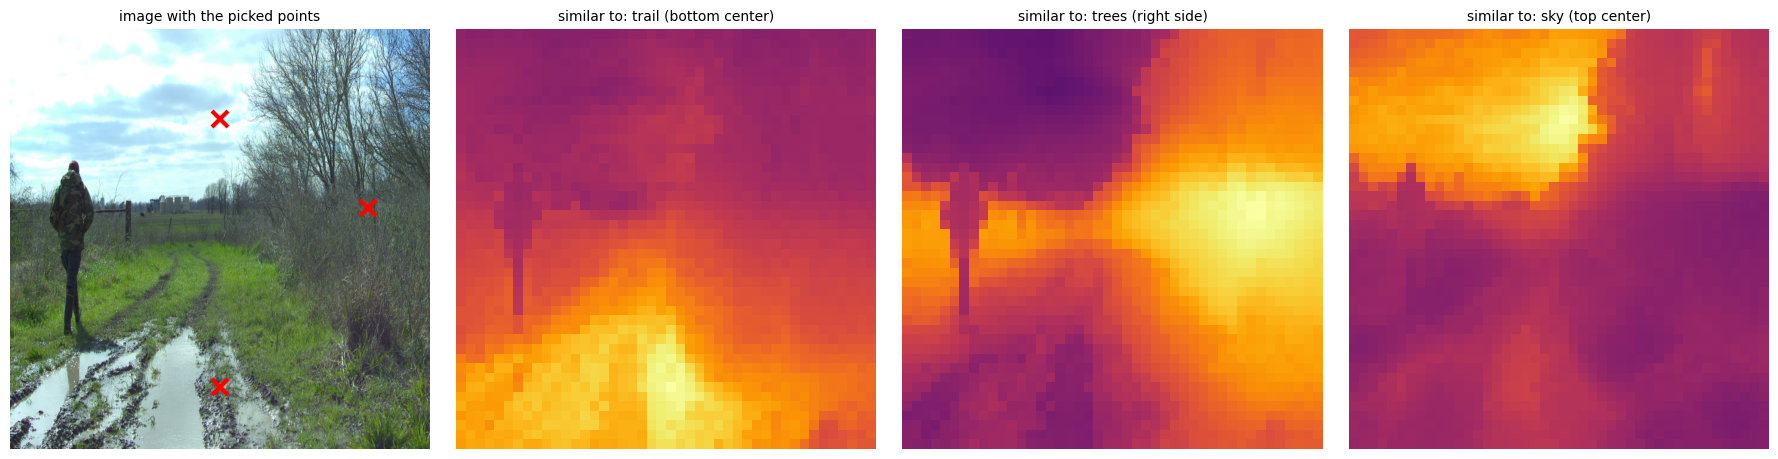

In [6]:
# points given in 704x704 coordinates (x = right, y = down) 
POINTS = [
    (352, 600, 'trail (bottom center)'),
    (600, 300, 'trees (right side)'),
    (352, 150, 'sky (top center)'),
]

def similarity_map(feature_map, x, y):
    """Cosine similarity of every patch to the patch under pixel (x, y)."""
    row = y // PATCH                                   # which grid cell is under the pixel
    col = x // PATCH
    reference = feature_map[row, col]                  # (384,)
    flat = feature_map.reshape(-1, feature_map.shape[2])
    # cosine similarity = dot product of unit-length vectors
    flat_unit = flat / np.linalg.norm(flat, axis=1, keepdims=True)
    ref_unit = reference / np.linalg.norm(reference)
    sim = flat_unit @ ref_unit                         # (1936,)
    return sim.reshape(feature_map.shape[0], feature_map.shape[1])

fig, axes = plt.subplots(1, len(POINTS) + 1, figsize=(4.5 * (len(POINTS) + 1), 4.5))
axes[0].imshow(square)
for x, y, name in POINTS:
    axes[0].plot(x, y, marker='x', markersize=12, markeredgewidth=3, color='red')
axes[0].set_title('image with the picked points', fontsize=10)

for ax, (x, y, name) in zip(axes[1:], POINTS):
    sim = similarity_map(features, x, y)
    ax.imshow(sim, cmap='inferno', vmin=-0.2, vmax=1.0)
    ax.set_title(f'similar to: {name}', fontsize=10)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'similarity.png', dpi=120)
plt.show()

## 5. The same PCA colors across different images

Here we **fit the PCA on the first image and reuse it** on images from other sequences. If
the features are consistent, the same terrain type should get roughly the same color in every
image — grass stays one color, trees another — even across different days and places.
That consistency is why an autoencoder trained on sequences 00000/1/3/4 works on 00002.

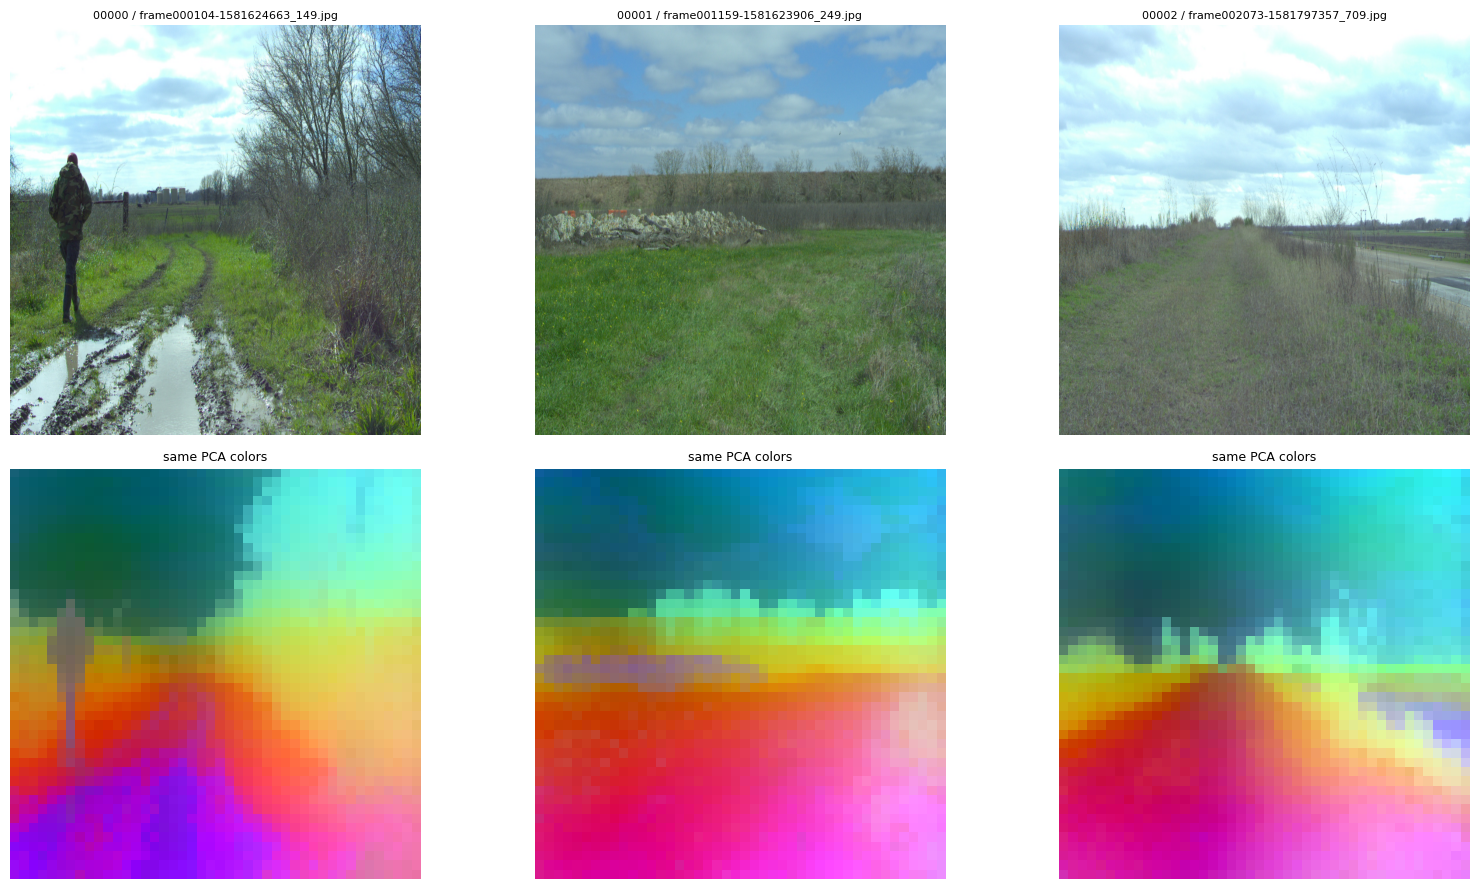

all figures saved to s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\viz_dinov3


In [7]:
# take the first readable image from each extra folder
other_images = []
for folder in EXTRA_IMAGES:
    files = sorted(folder.glob('*.jpg'))
    if len(files) > 0:
        other_images.append(files[len(files) // 2])    # middle of the sequence

all_paths = [IMAGE_PATH] + other_images
fig, axes = plt.subplots(2, len(all_paths), figsize=(5.5 * len(all_paths), 9))
for col, path in enumerate(all_paths):
    sq = load_square_image(path)
    fm = get_feature_map(sq)
    colors, _ = pca_color_image(fm, pca=pca)           # reuse the PCA fitted in section 3
    axes[0, col].imshow(sq)
    axes[0, col].set_title(path.parent.parent.name + ' / ' + path.name, fontsize=8)
    axes[1, col].imshow(colors)
    axes[1, col].set_title('same PCA colors', fontsize=9)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_across_images.png', dpi=120)
plt.show()
print('all figures saved to', OUT_DIR)